In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import wordcloud as Wc

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import (
    MultinomialNB,
    BernoulliNB,
    GaussianNB
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\finalReviews.csv")
print(df.shape)
df.head()





(302, 2)


,review,label
0,There isn't too much in the way of suspense or...,1
1,"I cried and laughed and blah, blah, blah. CGI ...",1
2,Not as good as infinity war..,1
3,First review from me. This film deserves it. A...,1
4,This film is an emotional rollercoaster with s...,1


# EDA


In [3]:
df.info()

print(df['label'].value_counts())

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  302 non-null    str  
 1   label   302 non-null    int64
dtypes: int64(1), str(1)
memory usage: 138.4 KB
label
1    170
0    132
Name: count, dtype: int64
review    0
label     0
dtype: int64


# Missing Values & Duplicate Handling

In [4]:
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print(df.shape)

(302, 2)


# Review Length Analysis

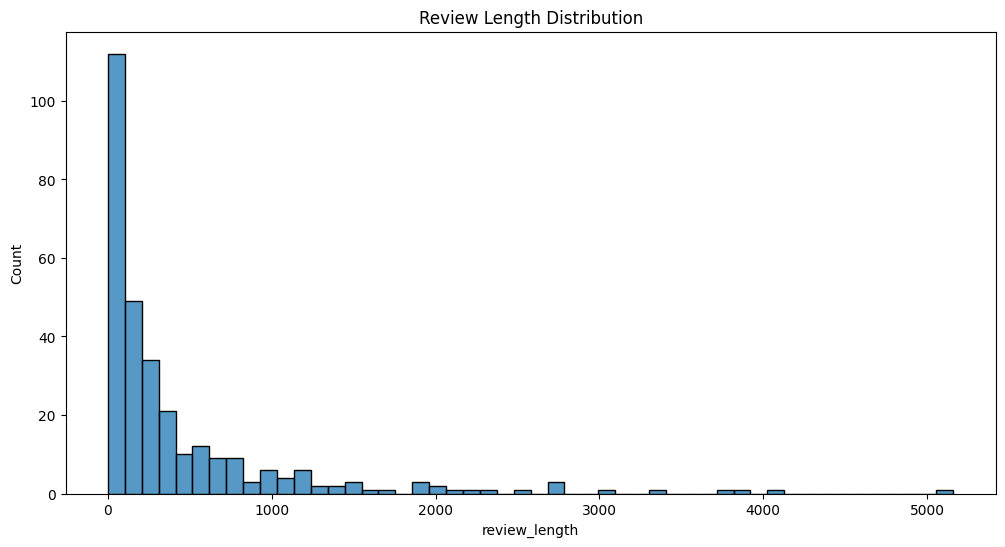

In [5]:
df["review_length"] = df["review"].apply(len)

plt.figure(figsize=(12,6))
sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()

#  Sentiment Distribution


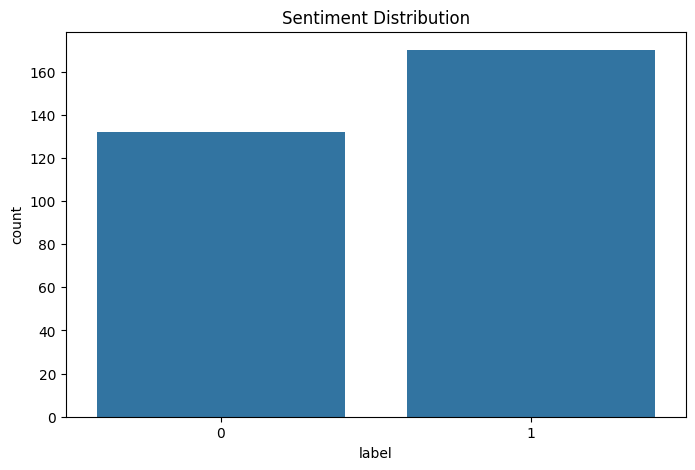

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

# WORD CLOUD

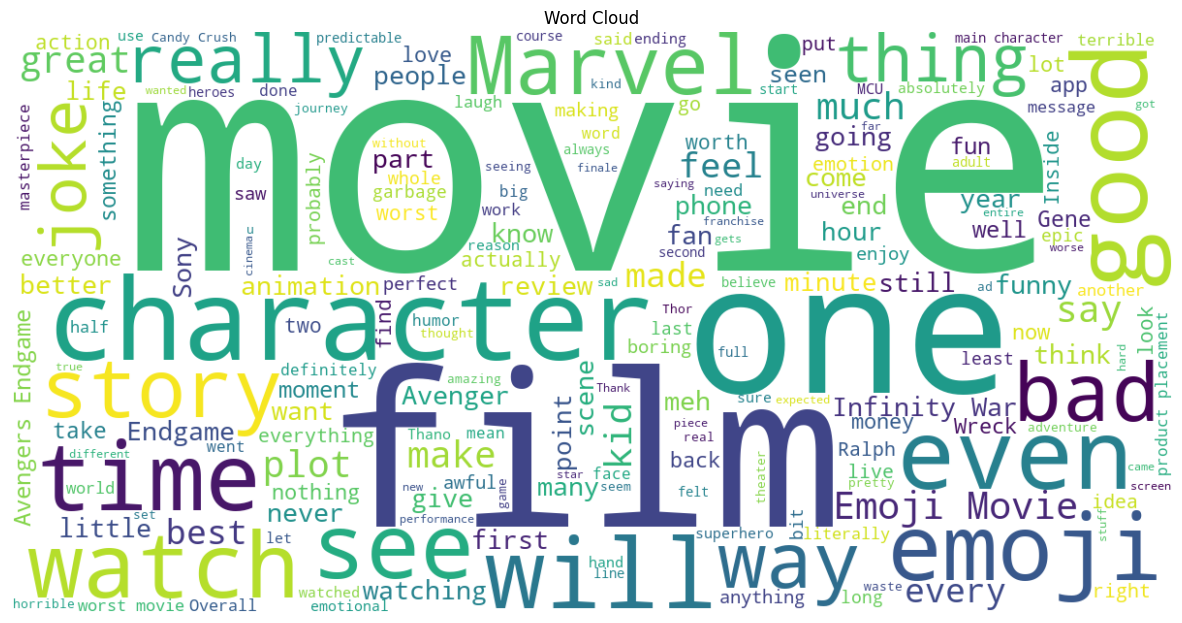

In [7]:
text = " ".join(df["review"])

from wordcloud import WordCloud

text = " ".join(df["review"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud")
plt.show()

# Train Test Split

In [8]:
X = df["review"]

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Transformation

In [9]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(241, 2560)


# Multinomial Naive Bayes

In [10]:
mnb = MultinomialNB()

mnb.fit(
    X_train_tfidf,
    y_train
)

mnb_pred = mnb.predict(X_test_tfidf)

print(classification_report(
    y_test,
    mnb_pred
))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84        27
           1       0.84      0.94      0.89        34

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61



# Bernoulli Naive Bayes

In [11]:
binary_vectorizer = CountVectorizer(
    binary=True,
    stop_words='english',
    max_features=10000
)

X_train_bin = binary_vectorizer.fit_transform(X_train)
X_test_bin = binary_vectorizer.transform(X_test)

bnb = BernoulliNB()

bnb.fit(
    X_train_bin,
    y_train
)

bnb_pred = bnb.predict(X_test_bin)

print(classification_report(
    y_test,
    bnb_pred
))

              precision    recall  f1-score   support

           0       0.81      0.48      0.60        27
           1       0.69      0.91      0.78        34

    accuracy                           0.72        61
   macro avg       0.75      0.70      0.69        61
weighted avg       0.74      0.72      0.71        61



# Gaussian Naive Bayes

In [12]:
gnb = GaussianNB()

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

gnb.fit(
    X_train_dense,
    y_train
)

gnb_pred = gnb.predict(
    X_test_dense
)

print(classification_report(
    y_test,
    gnb_pred
))

              precision    recall  f1-score   support

           0       0.60      0.78      0.68        27
           1       0.77      0.59      0.67        34

    accuracy                           0.67        61
   macro avg       0.68      0.68      0.67        61
weighted avg       0.69      0.67      0.67        61



# Performance Comparison

In [13]:
models = {
    "MultinomialNB":mnb_pred,
    "BernoulliNB":bnb_pred,
    "GaussianNB":gnb_pred
}

results=[]

for name,pred in models.items():

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1
0,MultinomialNB,0.868852,0.842105,0.941176,0.888889
1,BernoulliNB,0.721311,0.688889,0.911765,0.784810
2,GaussianNB,0.672131,0.769231,0.588235,0.666667


# Metrics Visualization

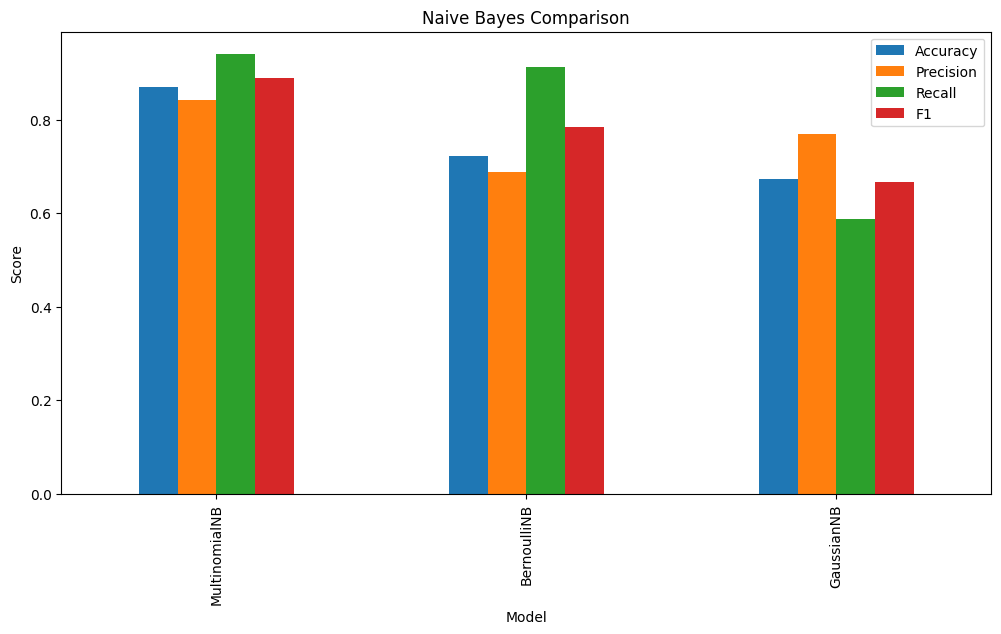

In [14]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Naive Bayes Comparison")
plt.ylabel("Score")
plt.show()

# ROC Curve (Professional)

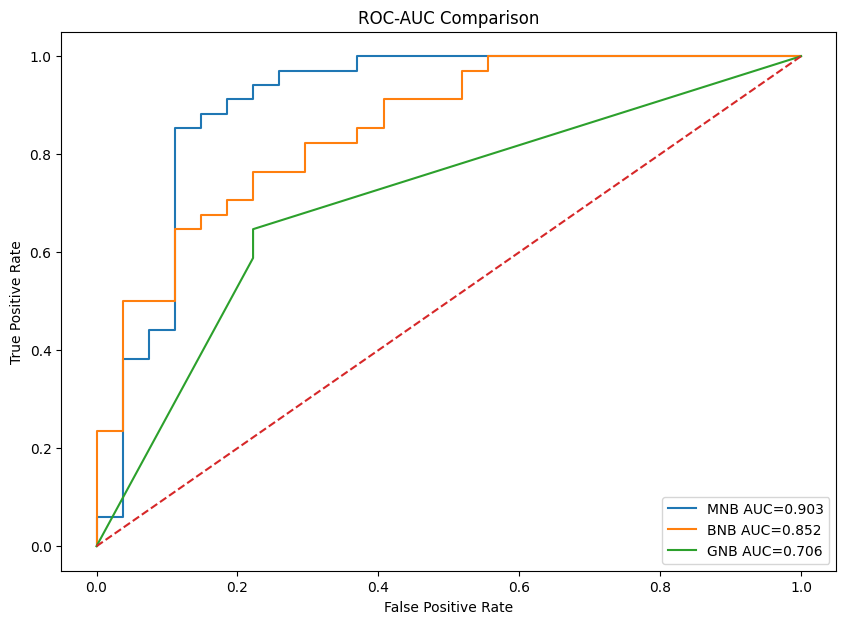

In [15]:
plt.figure(figsize=(10,7))

for model,name,data in [

    (mnb,"MNB",X_test_tfidf),

    (bnb,"BNB",X_test_bin),

    (gnb,"GNB",X_test_dense)

]:

    probs = model.predict_proba(data)[:,1]

    fpr,tpr,_ = roc_curve(
        y_test,
        probs
    )

    auc_score = roc_auc_score(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc_score:.3f}"
    )

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Comparison")
plt.legend()

plt.show()

# Advanced Probability Analysis Cell

In [16]:
feature_names = tfidf.get_feature_names_out()

top_words = pd.DataFrame({
    "Word":feature_names,
    "Probability":mnb.feature_log_prob_[1]
})

top_words.sort_values(
    by="Probability",
    ascending=False
).head(20)

,Word,Probability
1480,movie,-5.739613
1398,marvel,-6.130689
1000,good,-6.137044
1171,infinity,-6.177463
1017,great,-6.232229
182,avengers,-6.247421
2466,war,-6.257331
732,endgame,-6.300574
228,best,-6.344212
1,10,-6.374584


# Model Saving

In [17]:
import joblib

joblib.dump(
    mnb,
    "multinomial_nb.pkl"
)

joblib.dump(
    tfidf,
    "vectorizer.pkl"
)

['vectorizer.pkl']

# Real-Time Prediction

In [18]:
sample_review = """
This movie was absolutely fantastic.
The acting was brilliant and storyline was engaging.
"""

sample_vector = tfidf.transform([sample_review])

prediction = mnb.predict(sample_vector)[0]

probability = mnb.predict_proba(sample_vector)[0]

print("Prediction:", prediction)

print("Negative Probability:",
      round(probability[0]*100,2),"%")

print("Positive Probability:",
      round(probability[1]*100,2),"%")

Prediction: 1
Negative Probability: 29.28 %
Positive Probability: 70.72 %


# User Input Prediction

In [19]:
import os

print(os.getcwd())
print(os.listdir())

c:\ds and AI\ALL DATASETS\IMDB analysis prediction with naive bayes algorithm project
['app.py', 'IMDB analysis prediction naive bayes.ipynb', 'models', 'multinomial_nb.pkl', 'vectorizer.pkl']


In [20]:
import pandas as pd

df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\finalReviews.csv")

print(df.shape)
df.head()

(302, 2)


,review,label
0,There isn't too much in the way of suspense or...,1
1,"I cried and laughed and blah, blah, blah. CGI ...",1
2,Not as good as infinity war..,1
3,First review from me. This film deserves it. A...,1
4,This film is an emotional rollercoaster with s...,1


In [21]:
print(df.head())
print(df.columns)

                                              review  label
0  There isn't too much in the way of suspense or...      1
1  I cried and laughed and blah, blah, blah. CGI ...      1
2                      Not as good as infinity war..      1
3  First review from me. This film deserves it. A...      1
4  This film is an emotional rollercoaster with s...      1
Index(['review', 'label'], dtype='str')


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# train_model.py

In [24]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\finalReviews.csv")

X = df["review"]
y = df["label"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train = tfidf.fit_transform(X_train)

model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

joblib.dump(
    model,
    "models/mnb_model.pkl"
)

joblib.dump(
    tfidf,
    "models/tfidf.pkl"
)

print("Training Complete")

Training Complete


In [25]:
import joblib

joblib.dump(
    mnb,
    "multinomial_nb.pkl"
)

joblib.dump(
    tfidf,
    "vectorizer.pkl"
)

['vectorizer.pkl']